# Model Evaluation — Employee Attrition

This notebook independently evaluates the same four models used in Model Training:

- Logistic Regression
- Random Forest
- SVM
- Gradient Boosting

The same 80/20 stratified split (`random_state=42`) and preprocessing are used for a fair comparison.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, roc_curve,
    precision_recall_curve
)


In [12]:
data_candidates = [
    Path("../data/employee_attrition_selected.csv"),
    Path("backend/data/employee_attrition_selected.csv"),
    Path("/mnt/data/employee_attrition_selected.csv")
]

data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("employee_attrition_selected.csv not found.")

df = pd.read_csv(data_path)
X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)


## Train the four models

In [13]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42))
    ]),
    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

class_counts = y_train.value_counts()
sample_weights = np.where(
    y_train == 1,
    len(y_train) / (2 * class_counts[1]),
    len(y_train) / (2 * class_counts[0])
)

for name, model in models.items():
    if name == "Gradient Boosting":
        model.fit(X_train, y_train, model__sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
Random Forest trained successfully!
SVM trained successfully!
Gradient Boosting trained successfully!


In [14]:
predictions = {}
probabilities = {}
rows = []

for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    predictions[name] = pred
    probabilities[name] = prob

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

evaluation = pd.DataFrame(rows).sort_values(
    by=["F1 Score", "Recall", "ROC-AUC"], ascending=False
).reset_index(drop=True)

evaluation.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,SVM,0.8197,0.4516,0.5957,0.5138,0.8105,0.5368
1,Logistic Regression,0.7721,0.3864,0.7234,0.5037,0.8188,0.5535
2,Gradient Boosting,0.7959,0.3818,0.4468,0.4118,0.7774,0.4670
3,Random Forest,0.8435,0.5556,0.1064,0.1786,0.8105,0.4442


## Final comparison

Since this is an imbalanced binary classification problem and no specific business cost function has been defined, **F1-score is used as the primary model-selection metric** because it balances Precision and Recall. **Recall, Precision, ROC-AUC, and PR-AUC are supporting metrics**, while Accuracy is reported but is not used alone to select the final model.

The model with the highest F1-score is recommended as the final model. If two models have the same F1-score, Recall and then ROC-AUC are used as tie-breakers.

In [15]:
display(evaluation.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1 Score": "{:.2%}",
    "ROC-AUC": "{:.2%}",
    "PR-AUC": "{:.2%}"
}))

best_model_name = evaluation.iloc[0]["Model"]
print("\nRecommended final model (F1-score first):", best_model_name)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,SVM,81.97%,45.16%,59.57%,51.38%,81.05%,53.68%
1,Logistic Regression,77.21%,38.64%,72.34%,50.37%,81.88%,55.35%
2,Gradient Boosting,79.59%,38.18%,44.68%,41.18%,77.74%,46.70%
3,Random Forest,84.35%,55.56%,10.64%,17.86%,81.05%,44.42%



Recommended final model (F1-score first): SVM


## Confusion Matrices

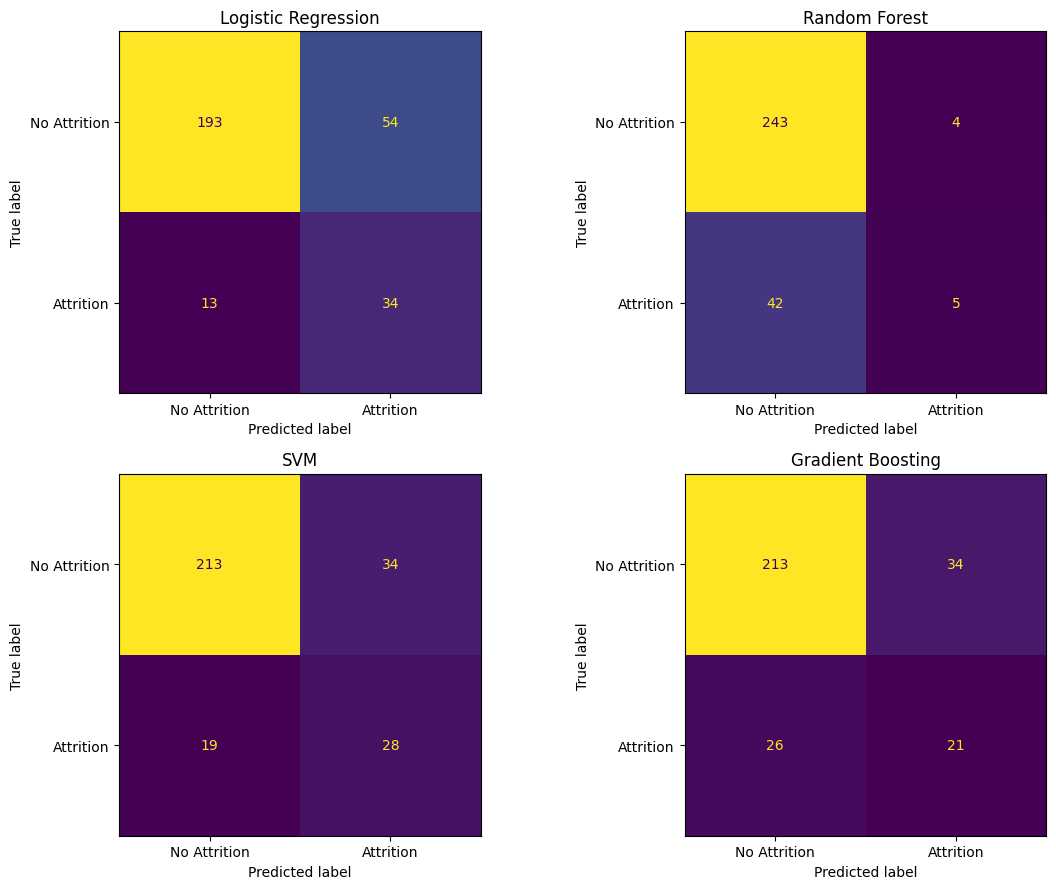

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=["No Attrition", "Attrition"]
    ).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## ROC Curves

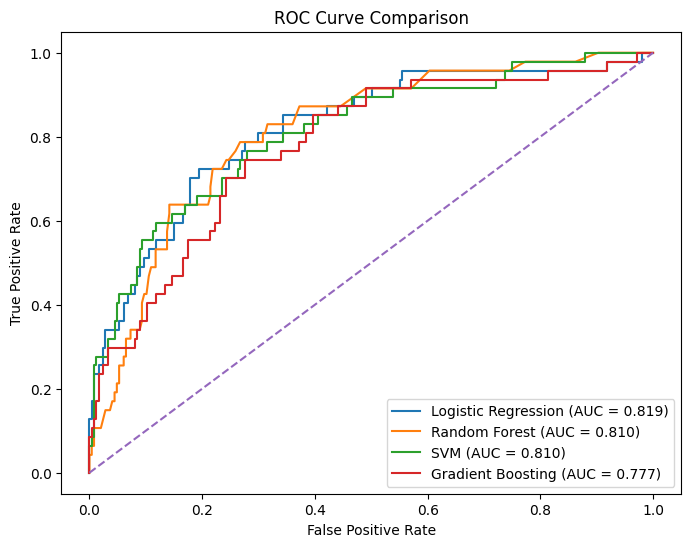

In [17]:
plt.figure(figsize=(8, 6))

for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Precision-Recall Curves

PR-AUC is especially useful here because `Attrition = Yes` is the minority class.

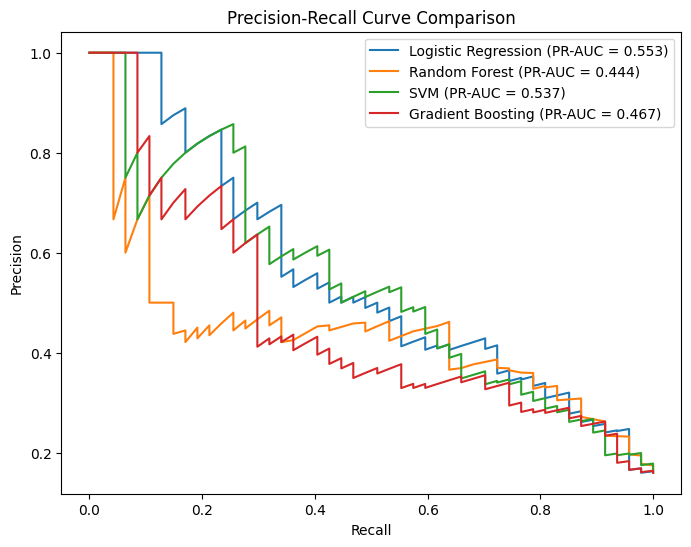

In [18]:
plt.figure(figsize=(8, 6))

for name, prob in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

## Classification Reports

In [19]:
for name, pred in predictions.items():
    print("\n" + "=" * 55)
    print(name)
    print("=" * 55)
    print(classification_report(
        y_test, pred,
        target_names=["No Attrition", "Attrition"],
        zero_division=0
    ))


Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.94      0.78      0.85       247
   Attrition       0.39      0.72      0.50        47

    accuracy                           0.77       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.77      0.80       294


Random Forest
              precision    recall  f1-score   support

No Attrition       0.85      0.98      0.91       247
   Attrition       0.56      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.55       294
weighted avg       0.81      0.84      0.80       294


SVM
              precision    recall  f1-score   support

No Attrition       0.92      0.86      0.89       247
   Attrition       0.45      0.60      0.51        47

    accuracy                           0.82       294
   macro avg       0.68      0.73      0.70       294
weighted avg       0.84      0.82

In [20]:
evaluation.to_csv("../models/model_comparison.csv", index=False)
print("Model comparison saved successfully!")

Model comparison saved successfully!
